In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

from previoABC import flujo_previo_ABC
from funciones import comprobar_dimensiones_ubic
from funciones2 import *

In [2]:
data_ABC = flujo_previo_ABC(region = "Los Santos", print_comprobacion_dimensiones = True)

True


In [3]:
# Calibración de modelos mediante Approximate Bayesian Computation (ABC)
dt_errores = pd.read_parquet('20260613_santos.parquet')

In [4]:
datos_santos_train = data_ABC["train"]
datos_santos_train_pivot = data_ABC["train_pivot"]
datos_santos_test = data_ABC["test"]
nsites_santos = data_ABC["nsites"]
nsites_training_santos = data_ABC["nsites_training"]
OLS_santos = data_ABC["OLS"]
ubic_santos = data_ABC["ubic"]
ubic_training_santos = data_ABC["ubic_training"]
dist_mat_santos = data_ABC["dist_mat"]
dist_mat_training_santos = data_ABC["dist_mat_training"]
m_training_santos = data_ABC["m_training"]

In [5]:
# Fecha corte para training
fecha_corte_2018 = pd.to_datetime('2018-12-31')

# Identificar Y_pred
# Aplica constante (promedio sobre exp(errores)) para volver a la escala original
datos_santos_train["Y_pred"] = np.mean(np.exp(datos_santos_train["logY_residuos"])) * np.exp(datos_santos_train["logY_pred"]) - 1
datos_santos_test["Y_pred"] = np.mean(np.exp(datos_santos_test["logY_residuos"])) * np.exp(datos_santos_test["logY_pred"]) - 1

In [6]:
# Modificaciones para generar simulaciones en testing
datos_santos_test2 = datos_santos_test[datos_santos_test['date'] > fecha_corte_2018]
datos_santos_test2_pivot = datos_santos_test2.pivot(index='date', columns=['lat','lon'], values='exp_residuos')
m_testing_santos = int(len(datos_santos_test2)/nsites_santos)

In [7]:
comprobar_dimensiones_ubic(ubic_santos, datos_santos_test2_pivot)

True

In [8]:
def estadisticos_reg_lineal(train, reg_lineal):
    print(reg_lineal.summary2())

    logY_residuos = train["logY_residuos"]

    # Heterocedasticidad (Breusch-Pagan)
    bp_test = sms.het_breuschpagan(logY_residuos, reg_lineal.model.exog)
    print(f"Breusch-Pagan test p-value: {bp_test[1]:.4f}")

def plot_modelo_regresion_lineal_global(datos):
    a = datos
    a_real = a["chirps"]
    a_log_Y = a["logY"]

    a_pred = a["Y_pred"]
    a_logY_pred = a["logY_pred"]
    
    a_logY_residuos = a["logY_residuos"]

    plt.figure()
    plt.scatter(a_real, a_pred)
    plt.plot([a_real.min(), a_real.max()],[a_real.min(), a_real.max()], linestyle='--')
    plt.xlabel("Y chirps")
    plt.ylabel("Y pred")
    plt.title("Y chirps vs Y pred")
    plt.show()

    plt.figure()
    plt.scatter(a_log_Y, a_logY_pred)
    plt.plot([a_log_Y.min(), a_log_Y.max()],[a_log_Y.min(), a_log_Y.max()], linestyle='--')
    plt.xlabel("Log Y chirps")
    plt.ylabel("Log Y pred")
    plt.title("Log Y chirps vs Log Y pred")
    plt.show()

    plt.figure()
    plt.scatter(a_logY_pred, a_logY_residuos)
    plt.axhline(0, linestyle='--')
    plt.xlabel("Log Y pred")
    plt.ylabel("Residuos")
    plt.title("Residuos vs Log Y pred")
    plt.show()

    plt.figure()
    sns.histplot(a_logY_residuos, kde=True)
    plt.title("Histograma de residuos")
    plt.ylabel("Conteos")
    plt.show()

    plt.figure()
    stats.probplot(a_logY_residuos, dist="norm", plot=plt)
    plt.title("QQ-plot Log Y residuos")
    plt.show()

    plt.figure()
    plt.scatter(a_logY_pred, np.sqrt(np.abs(a_logY_residuos)))
    plt.xlabel("Log Y pred")
    plt.ylabel("|Log Y residuos|^(1/2)")
    plt.title("Scale-Location")
    plt.show()
    
    plt.figure()
    plot_acf(a_logY_residuos, lags=30)
    plt.title("ACF Log Y residuos")
    plt.show()

In [9]:
# OLS
estadisticos_reg_lineal(datos_santos_train, OLS_santos)

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.829     
Dependent Variable: chirps           AIC:                12819.8877
Date:               2026-06-30 21:27 BIC:                12868.9777
No. Observations:   8208             Log-Likelihood:     -6402.9   
Df Model:           6                F-statistic:        6655.     
Df Residuals:       8201             Prob (F-statistic): 0.00      
R-squared:          0.830            Scale:              0.27891   
---------------------------------------------------------------------
           Coef.    Std.Err.       t       P>|t|     [0.025    0.975]
---------------------------------------------------------------------
const      4.7976     0.0058    823.0156   0.0000    4.7862    4.8090
lat       -0.1621     0.0058    -27.7478   0.0000   -0.1735   -0.1506
lon       -0.1346     0.0058    -23.0434   0.0000   -0.1460   -0.1231
sin_1     -1.2602     0.0082   -152.8627   0.0000   -1

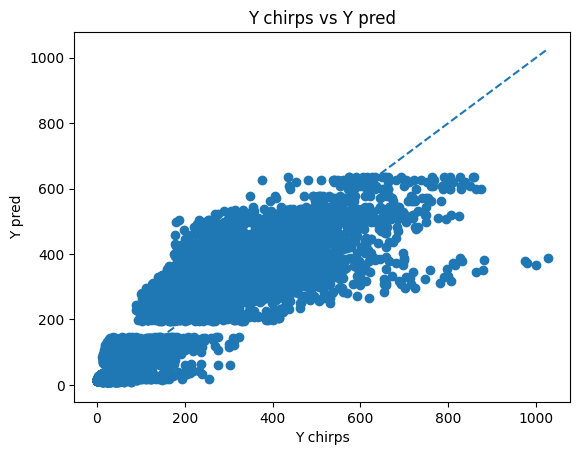

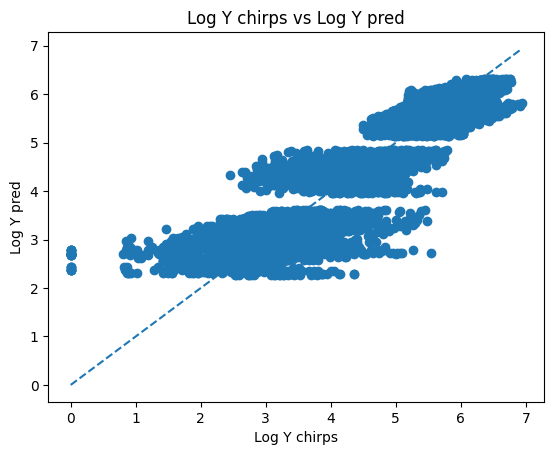

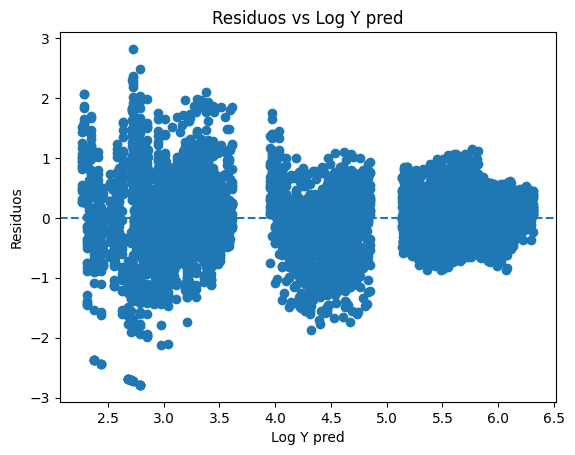

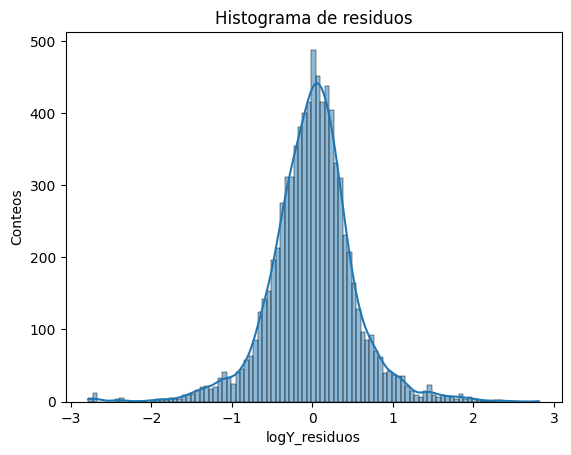

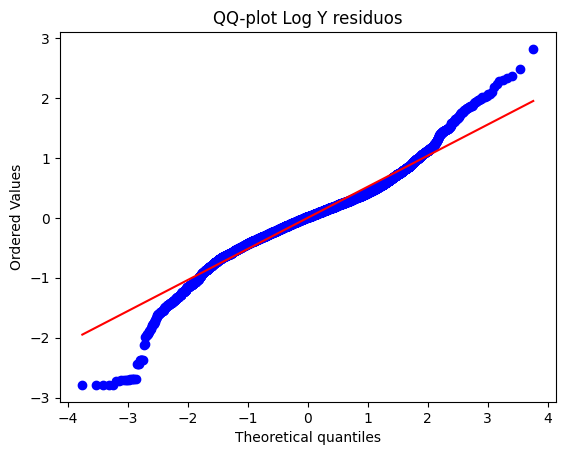

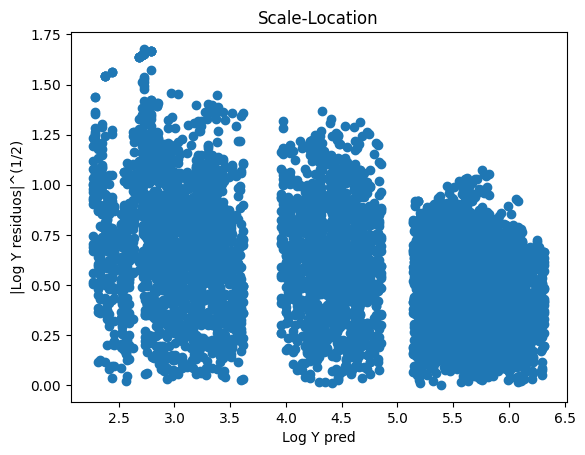

<Figure size 640x480 with 0 Axes>

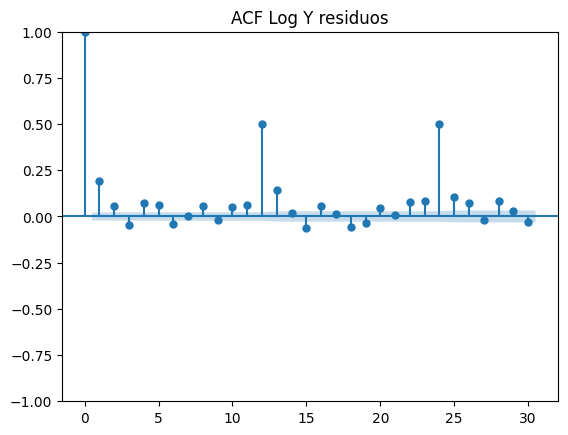

In [10]:
# Training
plot_modelo_regresion_lineal_global(datos_santos_train)

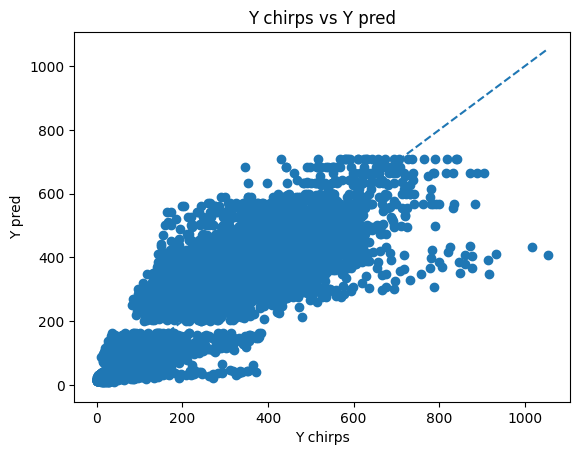

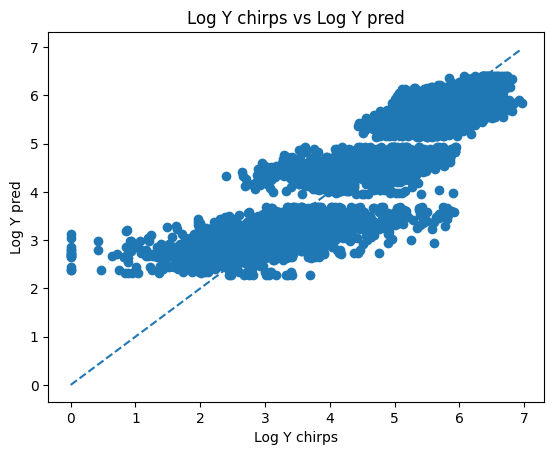

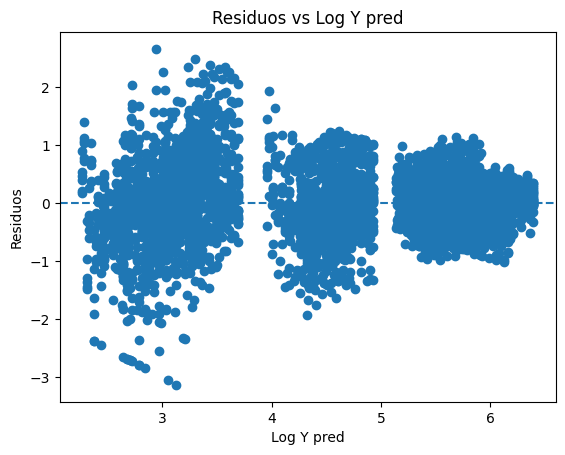

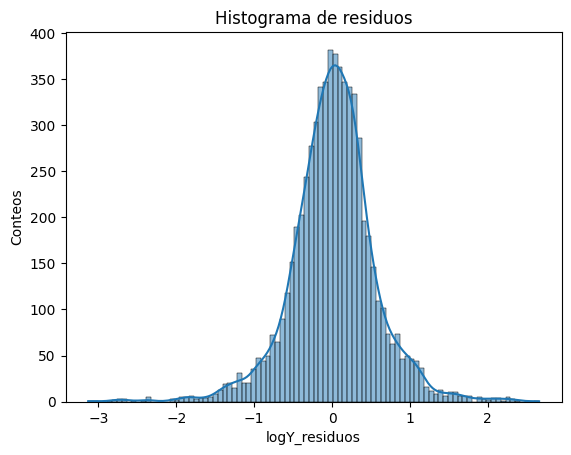

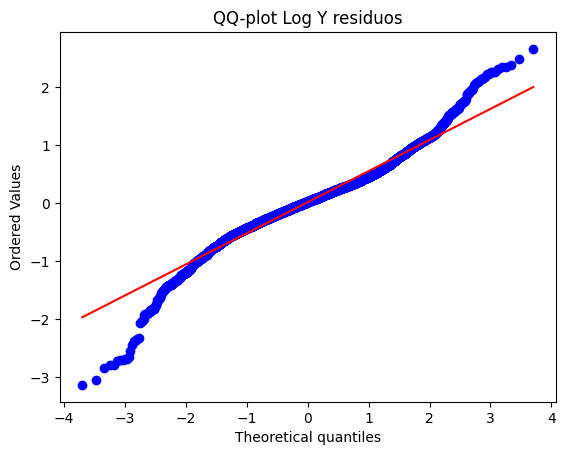

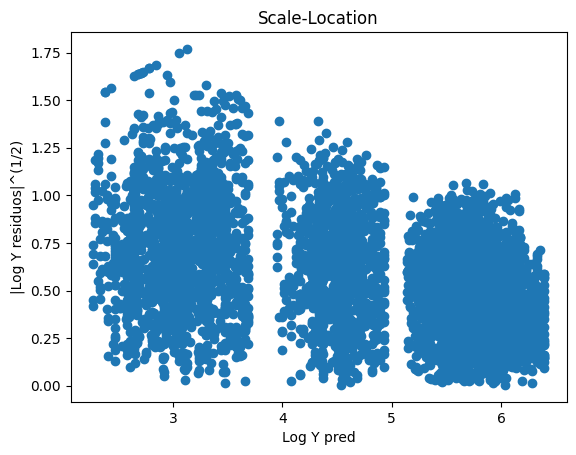

<Figure size 640x480 with 0 Axes>

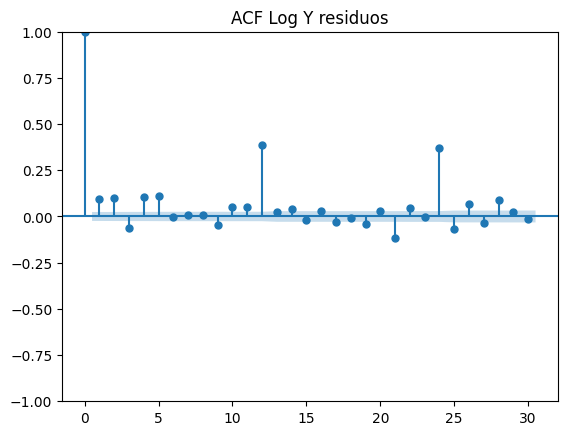

In [11]:
# Testing
plot_modelo_regresion_lineal_global(datos_santos_test)

In [12]:
def plot_modelo_regresion_lineal_ubic(datos, ubic, max_plots=10):
    count = 0

    for _, row in ubic.iterrows():
        lat, lon = row['lat'], row['lon']
        
        a = datos[(datos['lat'] == lat) & (datos['lon'] == lon)].copy()

        # Crear figura con 3 subplots
        fig, axes = plt.subplots(3, 1, figsize=(10, 8))

        # 1. Serie temporal
        axes[0].plot(a["date"], a["chirps"], label="chirps")
        axes[0].plot(a["date"], a["Y_pred"], label="Y_pred")
        axes[0].set_title(f"Lat={lat}, Lon={lon}")
        axes[0].set_ylabel("Precipitaciones")
        axes[0].legend()
        axes[0].grid()

        # 2. Residuos en log
        axes[1].plot(a["date"], a["logY_residuos"], label="LogY residuos")
        axes[1].axhline(0, linestyle='--')
        axes[1].set_ylabel("LogY residuos")
        axes[1].set_xlabel("Fecha")
        axes[1].grid()

        # 3. QQ-plot residuos
        stats.probplot(a["logY_residuos"], dist="norm", plot=axes[2])
        axes[2].set_title("QQ-plot LogY residuos")

        plt.tight_layout()
        plt.show()
    
        count += 1
        if count >= max_plots:
            break

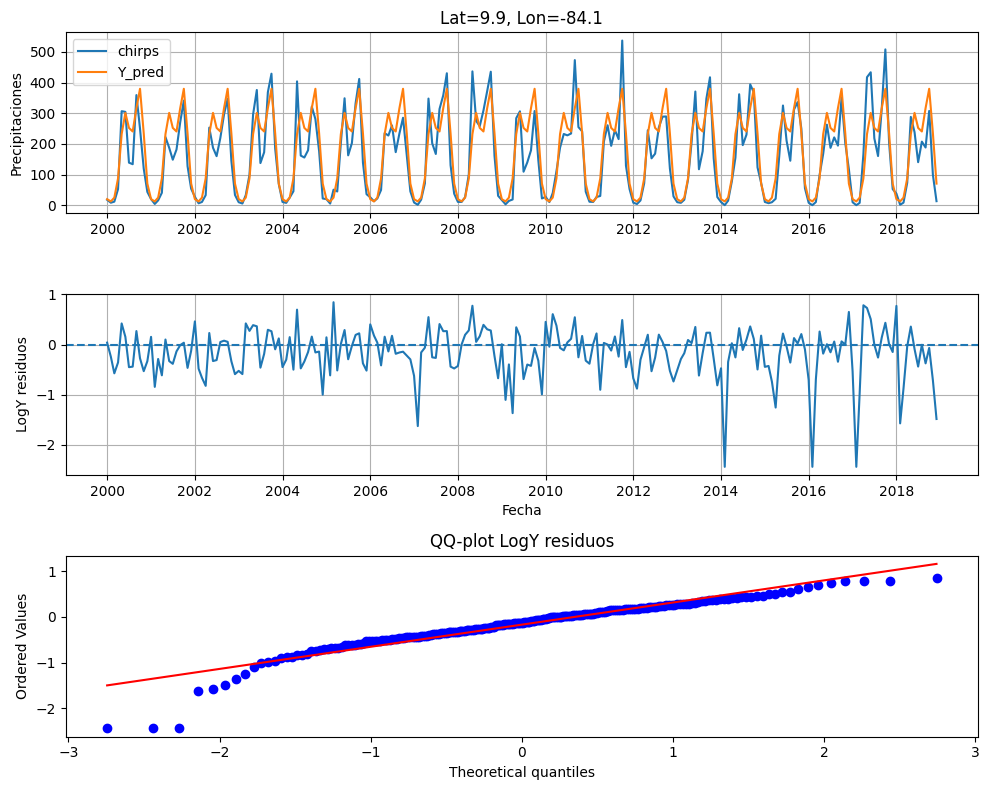

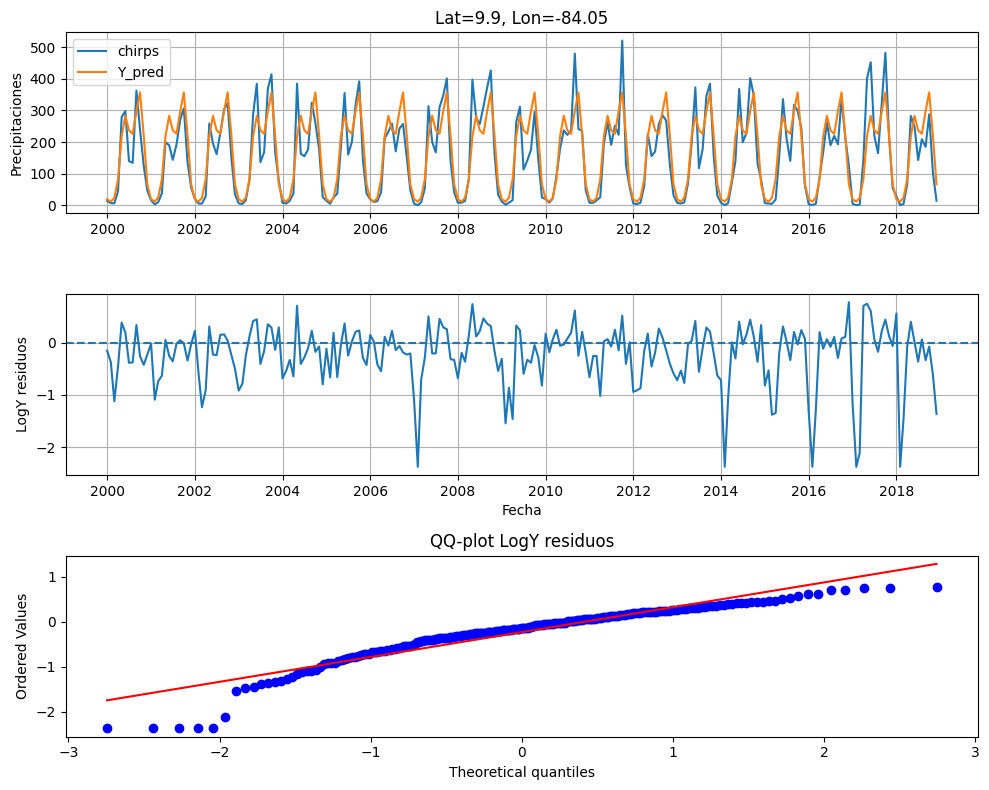

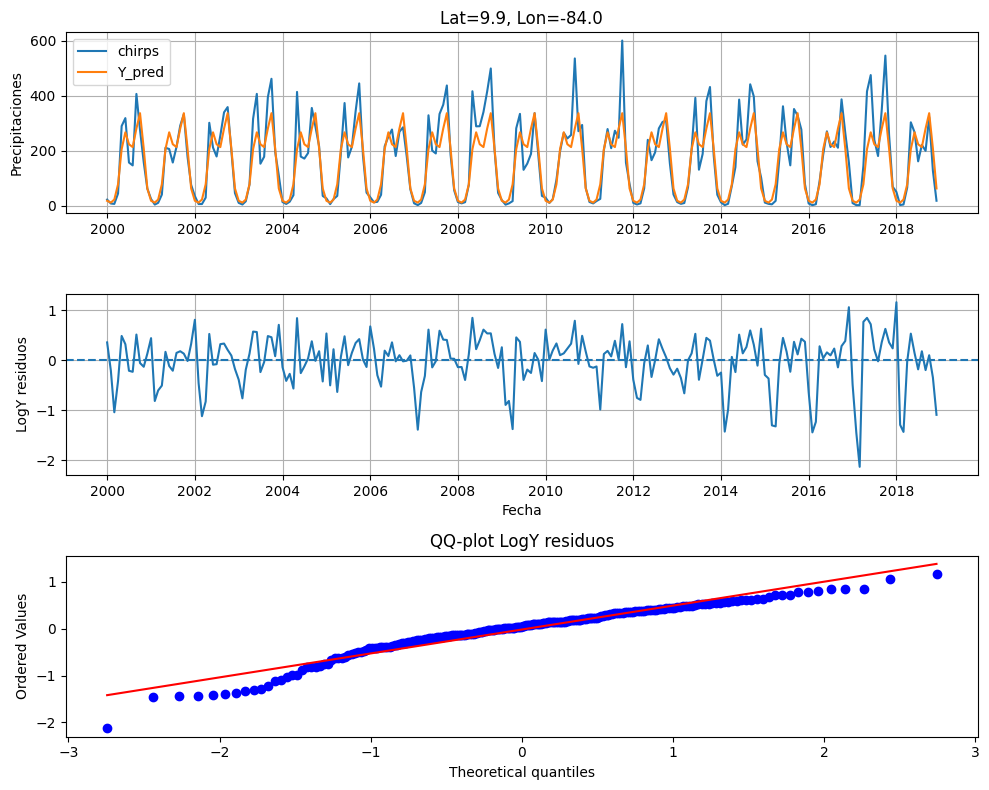

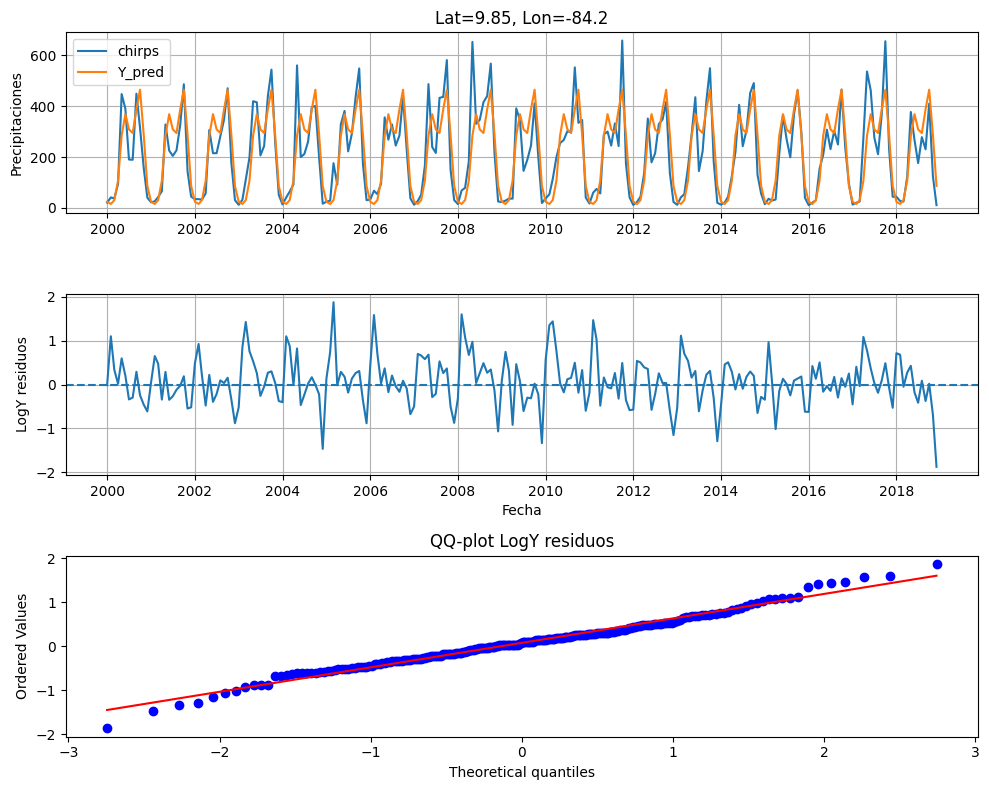

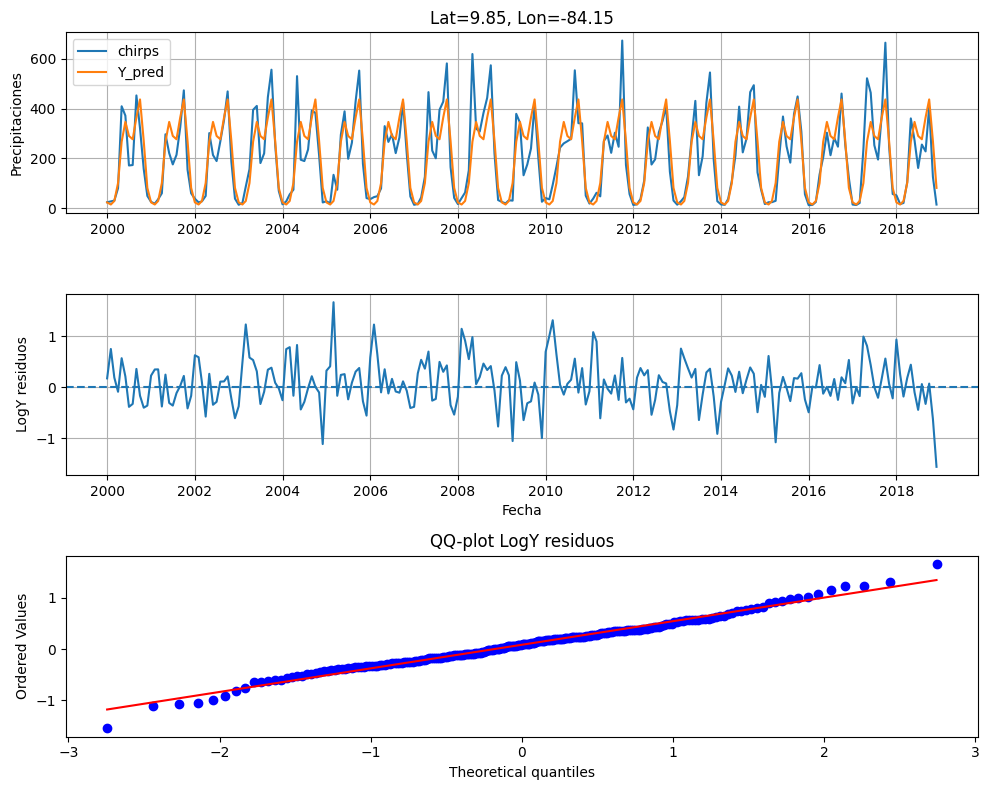

In [13]:
# Training
plot_modelo_regresion_lineal_ubic(datos_santos_train, ubic_training_santos, 5)

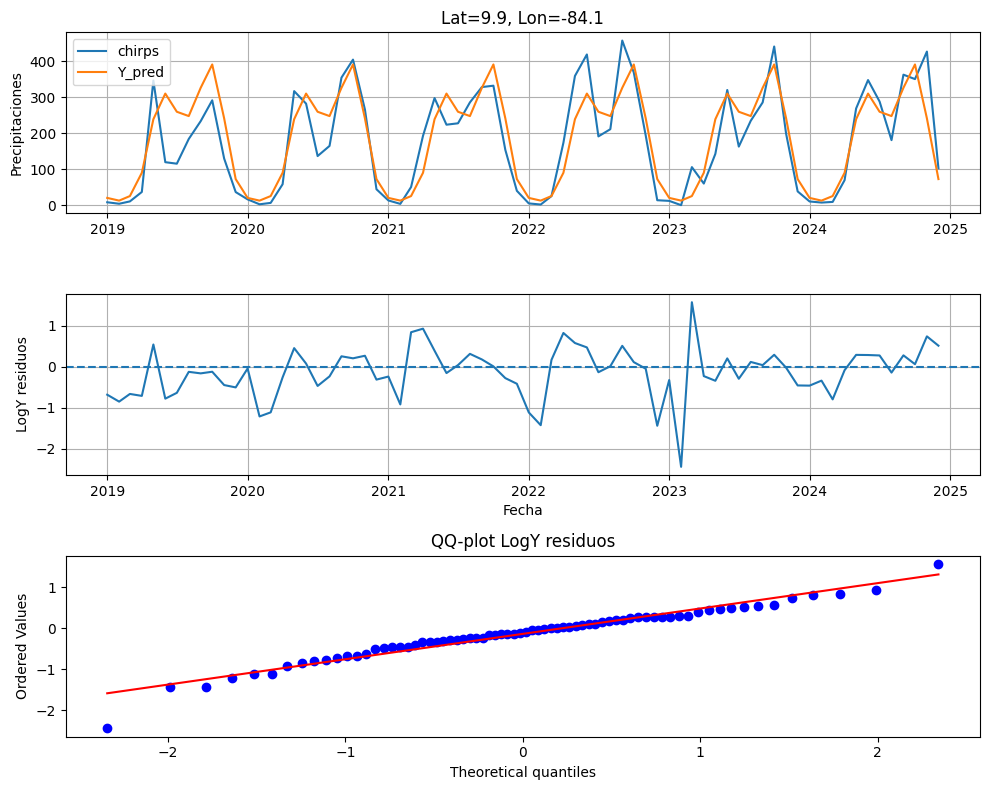

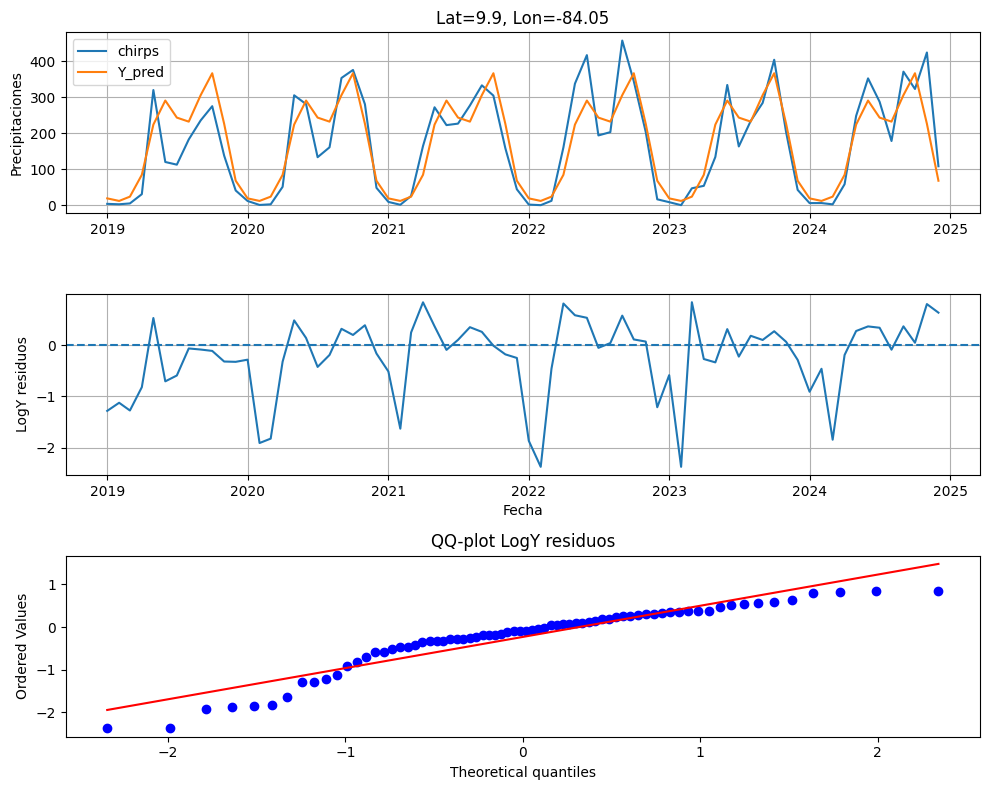

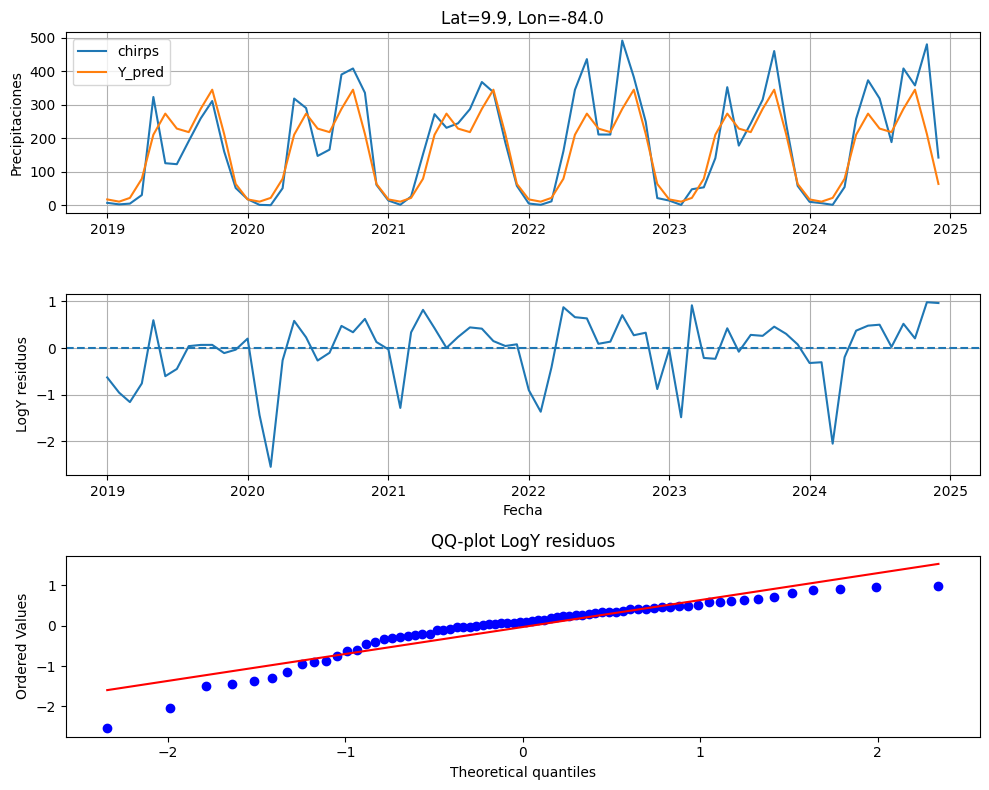

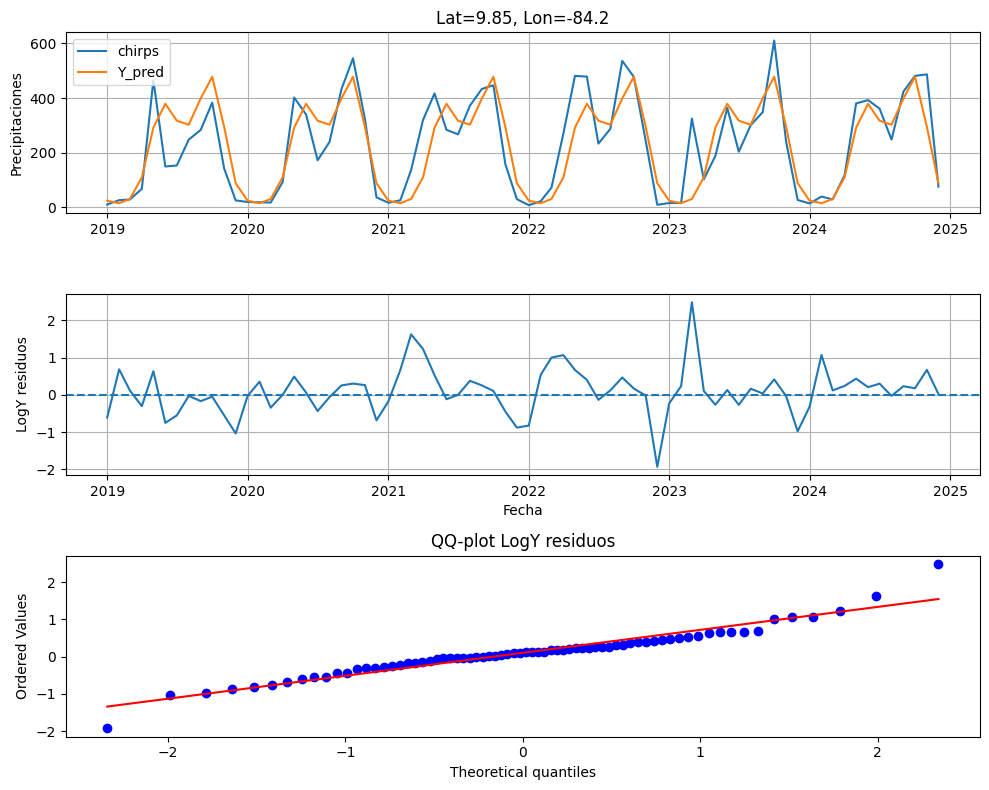

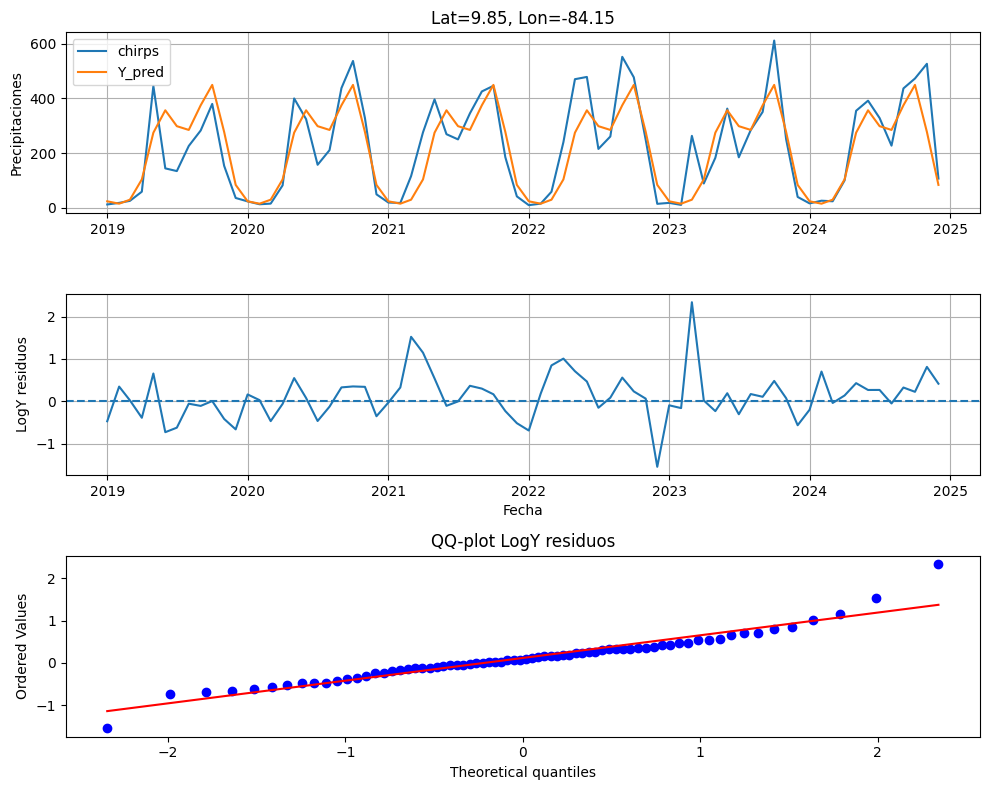

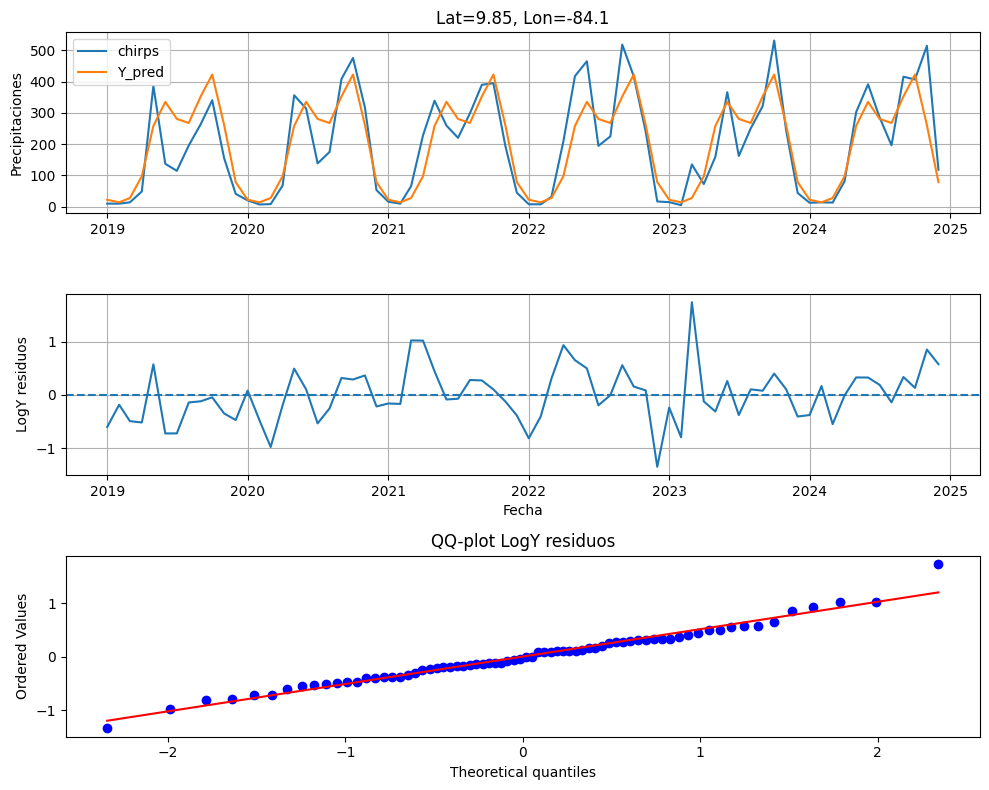

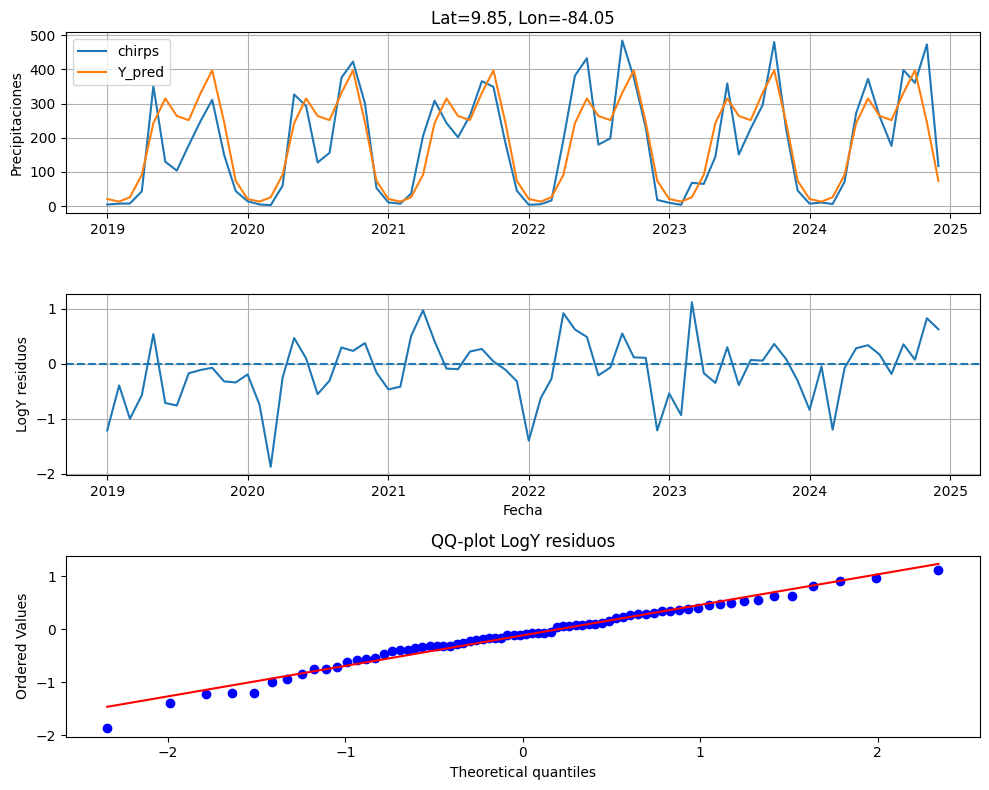

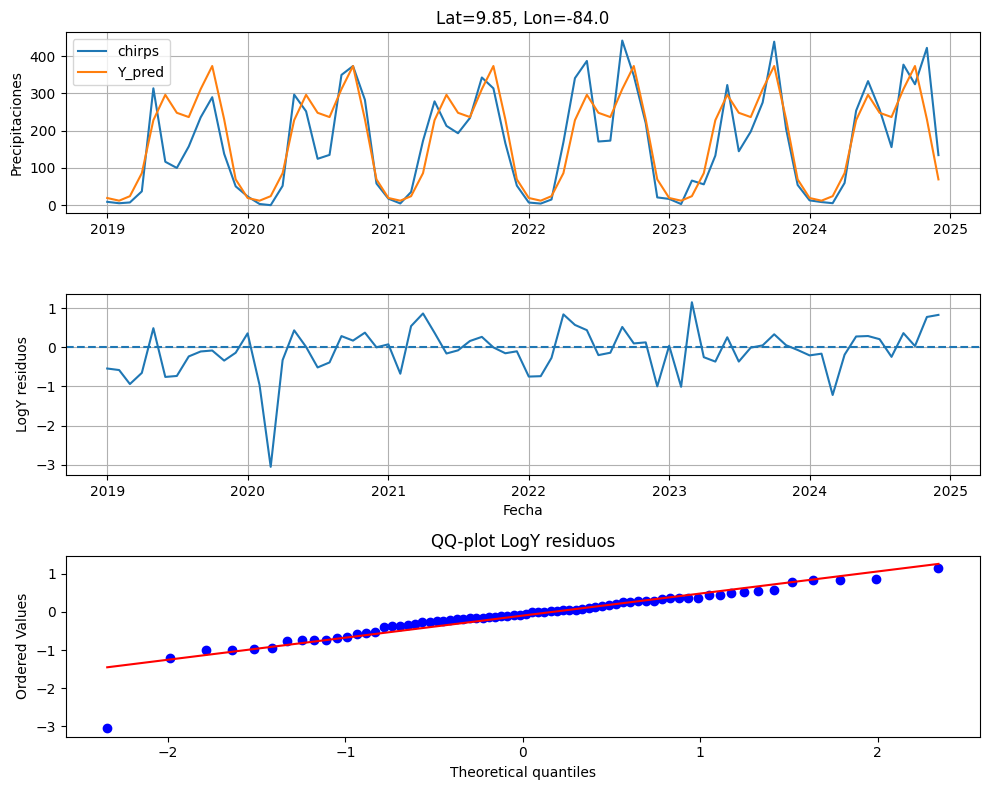

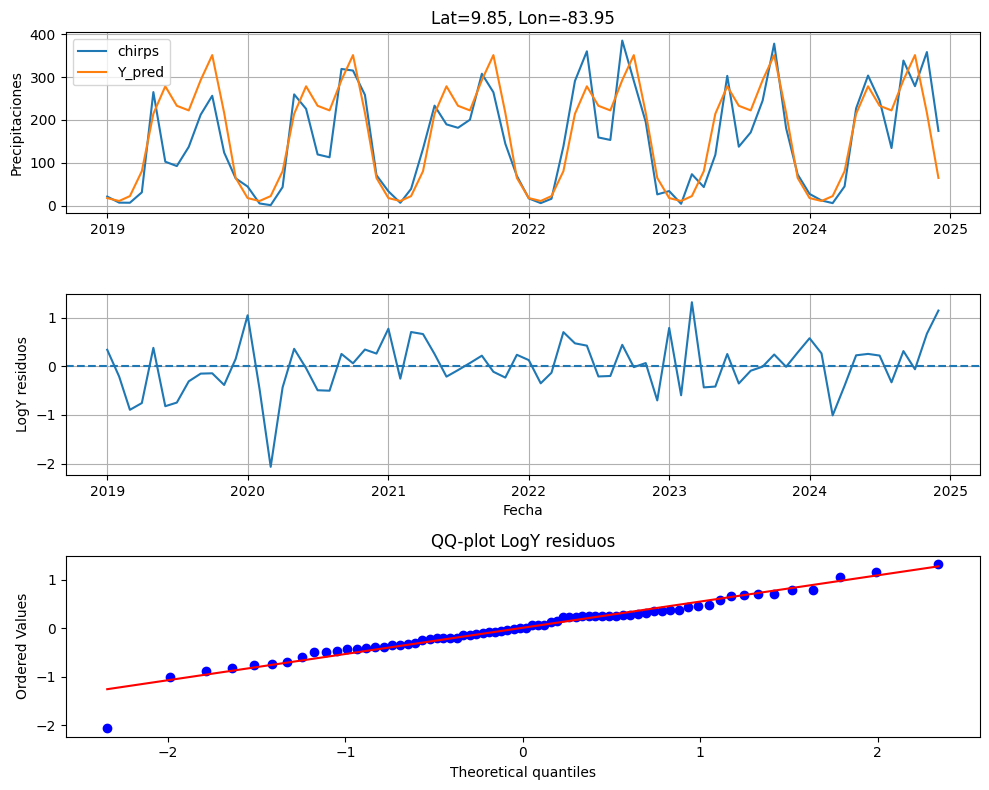

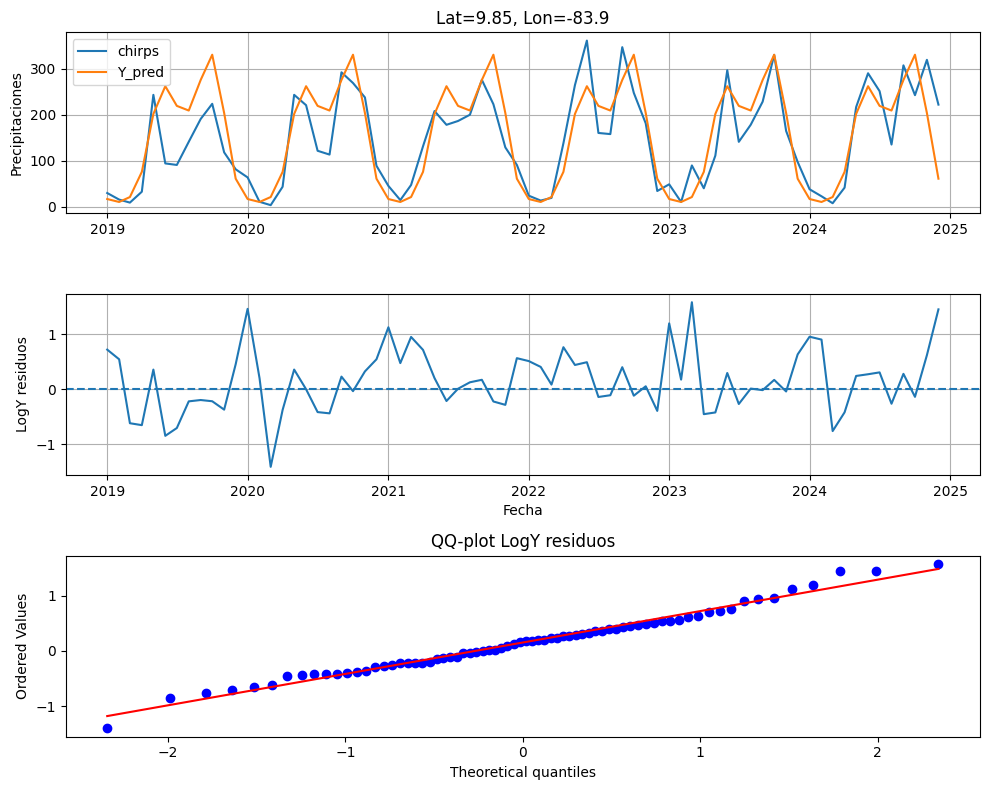

In [14]:
# Testing
plot_modelo_regresion_lineal_ubic(datos_santos_test, ubic_santos, 10) # nsites_santos)

In [15]:
# Definir mejor D y M
D_corrida, M_corrida = seleccionar_mejor_modelo(dt_errores, sort_by = 'mean_errorSWD', posicion_n_ranking = 0)
D_corrida, M_corrida = 'D5', 'M1'
print(D_corrida, M_corrida)

D5 M1


In [16]:
resumen_errores(dt_errores, sort_by = 'mean_errorSWD')

,modelo,covariables,mean_errorSWD,sd_errorSWD,mean_errorMSE,sd_errorMSE,min_errorSWD,max_errorSWD,min_errorMSE,max_errorMSE,iqr_SWD,iqr_MSE,p25_SWD,p25_MSE,p75_SWD,p75_MSE,n
2,D5,M1,9.001034,126.181835,6.074271e+06,1.908245e+09,0.214423,49270.664566,0.735161,9.396485e+11,4.624620,1863.851084,0.956709,10.928571,5.581330,1874.779655,250000
0,D3,M1,9.245503,98.324186,3.565204e+06,1.499381e+09,0.206242,44633.697476,0.717989,7.490556e+11,7.571058,2330.325548,0.487984,3.393605,8.059041,2333.719152,250000
4,D7,M1,25.724618,238.910165,1.871674e+07,2.832116e+09,0.217327,57300.304814,0.744283,9.801058e+11,15.812084,14562.674268,2.300783,56.828948,18.112867,14619.503216,250000
3,D6,M1,38.438463,436.342169,6.317147e+07,1.694124e+10,0.217958,157428.223006,0.725732,8.062586e+12,25.161004,19089.307962,1.196103,18.117361,26.357108,19107.425323,250000
1,D4,M1,38.755652,87.214137,9.062629e+05,4.728242e+07,0.206728,6381.089227,0.722473,1.333338e+10,35.275972,11307.255447,0.719277,3.705832,35.995248,11310.961279,250000
5,D8,M1,45.974804,499.864110,8.588257e+07,3.322714e+10,0.216627,217504.161079,0.734272,1.655267e+13,34.573532,30801.324755,2.779834,63.848253,37.353366,30865.173008,250000


In [17]:
def plot_simulaciones_exp_errores_vs_real(datos_pivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    exp_simulacion_errores = corrida_simulacion_exp_errores(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_pivot = datos_pivot)
    serie_simulaciones_promedio = exp_simulacion_errores.mean(axis=1)
    serie_original_exp_errores = datos_pivot.values.mean(axis=1)

    plt.plot(serie_simulaciones_promedio, label = "Simulaciones (sobre exp_errores)", color = "orange")
    plt.plot(serie_original_exp_errores, label = "Datos originales", color = "steelblue")
    plt.xlabel("Mes")
    plt.ylabel("")
    plt.title("Serie temporal de exp(errores)")
    plt.grid()
    plt.legend()
    plt.show()

Calibración con errorMSE:: 1.00, errorSWD:: 0.25, delta: 0.3315246993953188, phi: -0.07852141078416663, sigma: 0.24380514719811985, beta3: 6.2134837050044665, rho: 0.7653917578404026
Simulación con:: MSE: 1.14, MAE: 0.68, SWD: 0.26


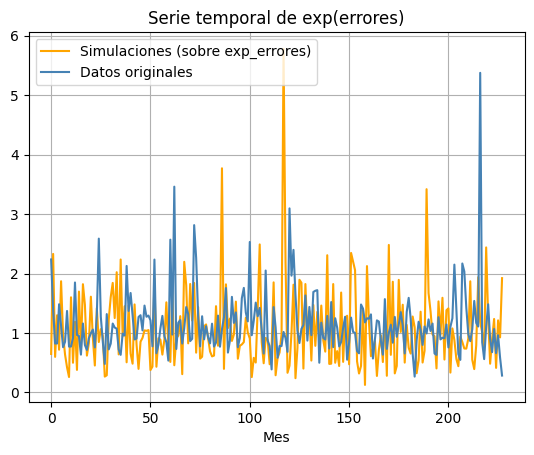

In [18]:
# Training
plot_simulaciones_exp_errores_vs_real(datos_santos_train_pivot, m_training_santos, nsites_training_santos, dist_mat_training_santos)

Calibración con errorMSE:: 0.98, errorSWD:: 0.22, delta: 0.30539406433149363, phi: 0.6183198449787856, sigma: 0.03613126759096075, beta3: 7.360218348360258, rho: 0.4250613330313503
Simulación con:: MSE: 1.36, MAE: 0.73, SWD: 0.24


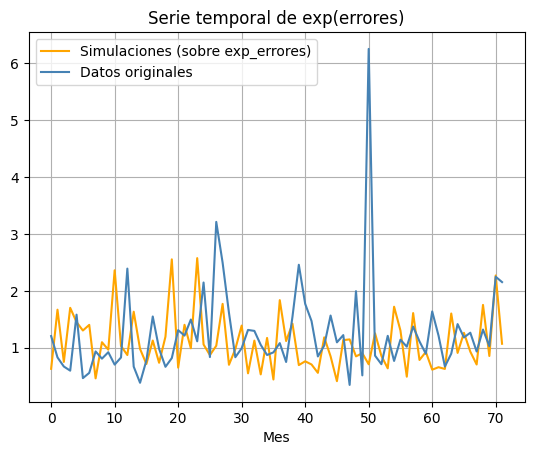

In [19]:
# Testing
plot_simulaciones_exp_errores_vs_real(datos_santos_test2_pivot, m_testing_santos, nsites_santos, dist_mat_santos)

In [20]:
def plot_simulaciones_vs_real(datos_prepivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    simulaciones_promedio = simulaciones.mean(axis=1)
    chirps_promedio = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='chirps').values.mean(axis=1)

    print_metricas_error_presimulaciones(datos_prepivot)
    print_metricas_error_simulaciones(simulaciones, datos_prepivot)

    plt.plot(simulaciones_promedio, label = "Simulaciones", color = "orange")
    plt.plot(chirps_promedio, label = "Datos originales", color = "steelblue")
    plt.xlabel("Mes")
    plt.ylabel("mm")
    plt.title("Precipitaciones mensuales promedio")
    plt.grid()
    plt.legend()
    plt.show()

Calibración con errorMSE:: 0.92, errorSWD:: 0.24, delta: 0.07806912785692177, phi: -0.16026907247065825, sigma: 0.19962468731006222, beta3: 7.245630801136184, rho: 0.8032972090946714
Regresión lineal con:: MSE: 6906.00, MAE: 58.39, SWD: 32.57
Simulación con:: MSE: 17106.30, MAE: 85.45, SWD: 27.65


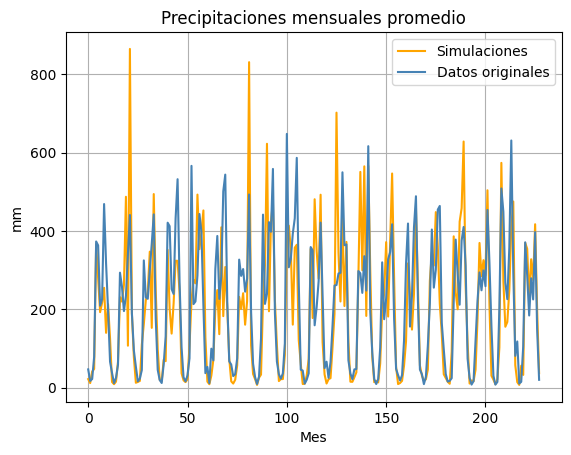

In [21]:
# Training
plot_simulaciones_vs_real(datos_santos_train, m_training_santos, nsites_training_santos, dist_mat_training_santos)

Calibración con errorMSE:: 1.10, errorSWD:: 0.29, delta: 0.06357449818277405, phi: -0.034291702845482, sigma: 0.5416012789878393, beta3: 5.792855285812166, rho: 0.8281665728869604
Regresión lineal con:: MSE: 8963.99, MAE: 68.37, SWD: 34.46
Simulación con:: MSE: 55606.35, MAE: 142.28, SWD: 79.87


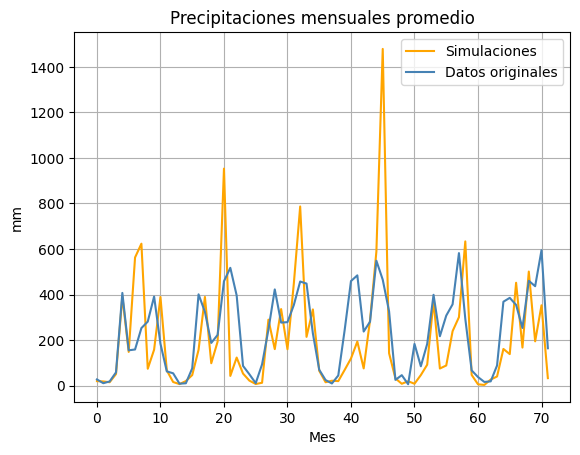

In [22]:
# Testing
plot_simulaciones_vs_real(datos_santos_test2, m_testing_santos, nsites_santos, dist_mat_santos)

In [23]:
def plot_qqplot_modelo_precipitaciones(datos_prepivot, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    datos_pivot = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='logY_pred')
    simulaciones_coords = asignar_coords_a_simulacion(simulaciones, datos_pivot)
    
    # Extraer vectores
    obs = datos_prepivot["chirps"].values
    sim = simulaciones_coords["simulaciones"].values

    # QQ
    q = np.linspace(0.01, 0.99, 100)
    obs_q = np.quantile(obs, q)
    sim_q = np.quantile(sim, q)

    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(obs_q, sim_q)

    # Identidad
    min_val = min(obs_q.min(), sim_q.min())
    max_val = max(obs_q.max(), sim_q.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Cuantiles observados")
    plt.ylabel("Cuantiles simulados")
    plt.title("QQ-plot global")
    plt.grid()
    plt.show()

Calibración con errorMSE:: 1.09, errorSWD:: 0.25, delta: 0.1978320610484866, phi: -0.29135375947974074, sigma: 0.17656814541660182, beta3: 4.42546004988352, rho: 0.4849012387626198


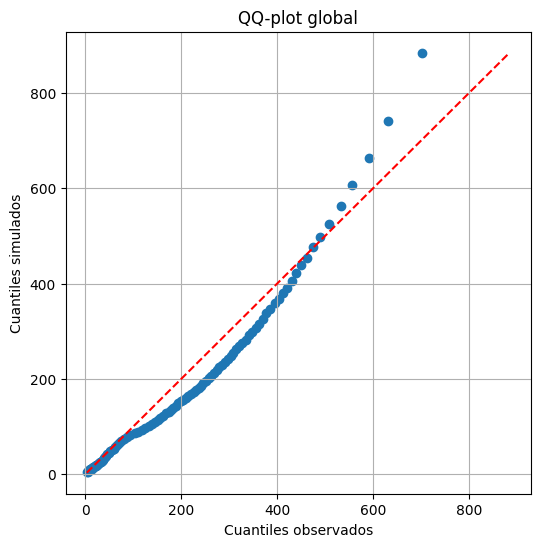

In [24]:
# Training
plot_qqplot_modelo_precipitaciones(datos_santos_train, m_training_santos, nsites_training_santos, dist_mat_training_santos, D_corrida, M_corrida)

Calibración con errorMSE:: 1.11, errorSWD:: 0.46, delta: 0.06361110027064198, phi: 0.834858133288774, sigma: 0.385604591534621, beta3: 7.213797579303174, rho: 0.26395265890631403


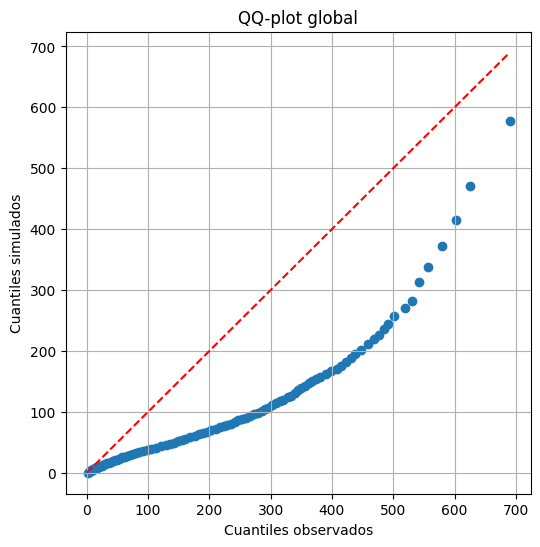

In [25]:
# Testing
plot_qqplot_modelo_precipitaciones(datos_santos_test2, m_testing_santos, nsites_santos, dist_mat_santos, D_corrida, M_corrida)

In [26]:
def plot_modelo_precipitaciones_ubic(datos_prepivot, ubic, m, nsites, dist_mat, D_elegido = D_corrida, M_elegido = M_corrida, max_plots=15):
    simulaciones = corrida_simulacion_precipitaciones(m, nsites, dist_mat, D_elegido, M_elegido, dt_errores, p = 0.01, id_simulacion = None, datos_prepivot = datos_prepivot)
    datos_pivot = datos_prepivot.pivot(index='date', columns=['lat','lon'], values='logY_pred')
    simulaciones_coords = asignar_coords_a_simulacion(simulaciones,datos_pivot)

    count = 0
    for _, row in ubic.iterrows():
        lat, lon = row['lat'], row['lon']

        a = datos_prepivot[(datos_prepivot['lat'] == lat) & (datos_prepivot['lon'] == lon)].copy()
        b = simulaciones_coords[(simulaciones_coords['lat'] == lat) & (simulaciones_coords['lon'] == lon)].copy()
        df_plot = a.merge(b, on=['date', 'lat', 'lon'])
        df_plot = df_plot.sort_values("date")

        # Crear figura
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        # 1. Serie temporal
        axes[0].plot(df_plot["date"], df_plot["chirps"], label="Observado")
        axes[0].plot(df_plot["date"], df_plot["simulaciones"], label="Simulaciones")
        axes[0].set_title(f"Lat={lat}, Lon={lon}")
        axes[0].set_ylabel("Precipitaciones")
        axes[0].legend()
        axes[0].grid()

        # 2. QQ-plot
        q = np.linspace(0.01, 0.99, 50)

        obs_q = np.quantile(df_plot["chirps"], q)
        sim_q = np.quantile(df_plot["simulaciones"], q)

        axes[1].scatter(obs_q, sim_q)

        min_val = min(obs_q.min(), sim_q.min())
        max_val = max(obs_q.max(), sim_q.max())

        axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')

        axes[1].set_title("QQ-plot (cuantiles)")
        axes[1].set_xlabel("Observado")
        axes[1].set_ylabel("Simulaciones")
        axes[1].grid()

        plt.tight_layout()
        plt.show()

        count += 1
        if count >= max_plots:
            break

Calibración con errorMSE:: 1.03, errorSWD:: 0.33, delta: 0.17263254983374898, phi: -0.5863308883352383, sigma: 0.5546722032533374, beta3: 7.056129625129783, rho: 0.6753533987653672


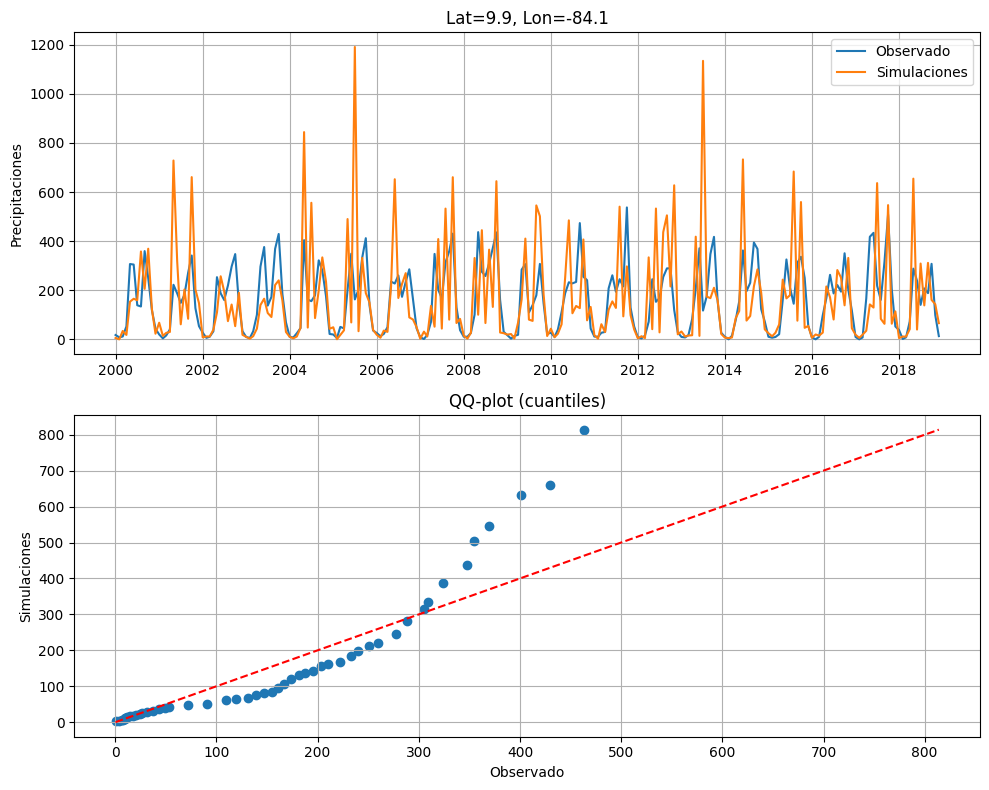

In [27]:
# Training
plot_modelo_precipitaciones_ubic(datos_santos_train, ubic_training_santos, m_training_santos, nsites_training_santos, dist_mat_training_santos, D_corrida, M_corrida, max_plots = 1)

Calibración con errorMSE:: 1.11, errorSWD:: 0.25, delta: 0.39205667901298813, phi: 0.020035553364052827, sigma: 0.25686161950342845, beta3: 7.082251676840231, rho: 0.8934684319700255


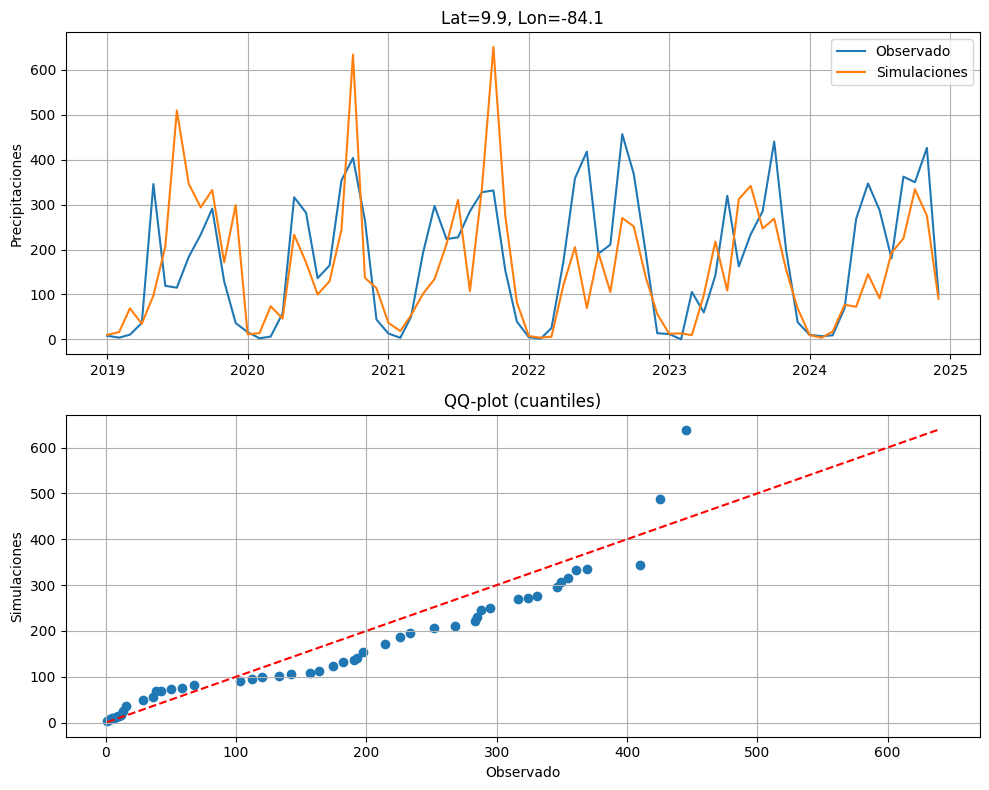

In [28]:
# Testing
plot_modelo_precipitaciones_ubic(datos_santos_test2, ubic_santos, m_testing_santos, nsites_santos, dist_mat_santos, D_corrida, M_corrida, max_plots = 1)

In [29]:
listado_percentiles(dt_errores)

,percentil,umbral_SWD,umbral_MSE
0,0.002,0.230280,0.835296
1,0.005,0.236323,0.870861
2,0.010,0.242945,0.921373
3,0.020,0.253731,1.020011
4,0.025,0.259678,1.073314
5,0.040,0.283538,1.258909
6,0.050,0.306001,1.407588
7,0.100,0.473828,2.363200
8,0.250,1.129893,13.249005


In [30]:
# Percentil 1% sobre TODAS las variantes de modelos
resumen_errores(filtrar_df_por_percentil(dt_errores, 'errorSWD', p = 0.01), sort_by = 'mean_errorMSE')

,modelo,covariables,mean_errorSWD,sd_errorSWD,mean_errorMSE,sd_errorMSE,min_errorSWD,max_errorSWD,min_errorMSE,max_errorMSE,iqr_SWD,iqr_MSE,p25_SWD,p25_MSE,p75_SWD,p75_MSE,n
1,D4,M1,0.235956,0.005314,0.936424,0.078629,0.206728,0.242944,0.722473,1.391417,0.007435,0.106062,0.232825,0.878665,0.240259,0.984727,5203
5,D8,M1,0.236503,0.005222,0.943579,0.072897,0.216627,0.242931,0.793404,1.162605,0.007515,0.104067,0.233436,0.889535,0.240951,0.993601,261
3,D6,M1,0.236099,0.005518,0.957301,0.080796,0.217958,0.242944,0.779342,1.236686,0.007655,0.111562,0.232876,0.898303,0.240530,1.009865,379
0,D3,M1,0.234590,0.006046,0.978958,0.105936,0.206242,0.242942,0.717989,1.503416,0.008784,0.147690,0.230790,0.897732,0.239573,1.045422,8152
4,D7,M1,0.235182,0.005783,0.987933,0.103631,0.217327,0.242918,0.791779,1.324082,0.008020,0.144341,0.231744,0.910882,0.239765,1.055223,461
2,D5,M1,0.234952,0.006010,0.990095,0.099413,0.214423,0.242917,0.787382,1.308321,0.008299,0.138559,0.231392,0.915439,0.239691,1.053998,544


In [31]:
# Percentil 1% asignado entre cada subgrupo de combinaciones de modelos
top1p = filtrar_df_errores_por_percentil_agrupado(dt_errores, "errorMSE", p = 0.01)

top1p.groupby(['modelo', 'covariables'], as_index=False).agg(
    mean_errorSWD=('errorSWD', 'mean'),
    sd_errorSWD = ('errorSWD', 'std'),
    mean_errorMSE = ('errorMSE', 'mean'),
    sd_errorMSE = ('errorMSE', 'std'),
    n = ('errorSWD', 'count')
).sort_values('mean_errorMSE', ascending=True)

,modelo,covariables,mean_errorSWD,sd_errorSWD,mean_errorMSE,sd_errorMSE,n
0,D3,M1,0.247992,0.011383,0.825800,0.022589,2500
1,D4,M1,0.248341,0.010907,0.828368,0.022952,2500
2,D5,M1,0.259892,0.021994,1.038318,0.106120,2500
3,D6,M1,0.264342,0.022229,1.045122,0.108983,2500
4,D7,M1,0.263293,0.022603,1.048341,0.111645,2500
5,D8,M1,0.270766,0.024113,1.053349,0.113033,2500


In [32]:
def histograma_parametros_modelo(dt_parametros, D_elegido, M_elegido, error_columna="errorSWD", p=0.01):
    previas_calibradas = ['delta', 'phi', 'sigma', 'beta3', 'rho']
    topXp = filtrar_df_errores_por_percentil_agrupado(dt_parametros, error_columna, p=p)
    df_modelo = topXp.loc[(topXp["modelo"] == D_elegido) & (topXp["covariables"] == M_elegido)]

    n = len(previas_calibradas)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
    axs = axs.flatten()

    for i, col in enumerate(previas_calibradas):
        ax = axs[i]
        if col in df_modelo.columns:
            ax.hist(df_modelo[col].dropna(), bins=20, color='tab:blue', edgecolor='black')
            ax.set_title(col, fontsize=10)
            ax.tick_params(labelsize=8)
        else:
            ax.set_visible(False)

    for j in range(i+1, len(axs)):
        axs[j].set_visible(False)

    plt.suptitle("Histogramas de parámetros", fontsize=14)
    plt.tight_layout()
    plt.show()

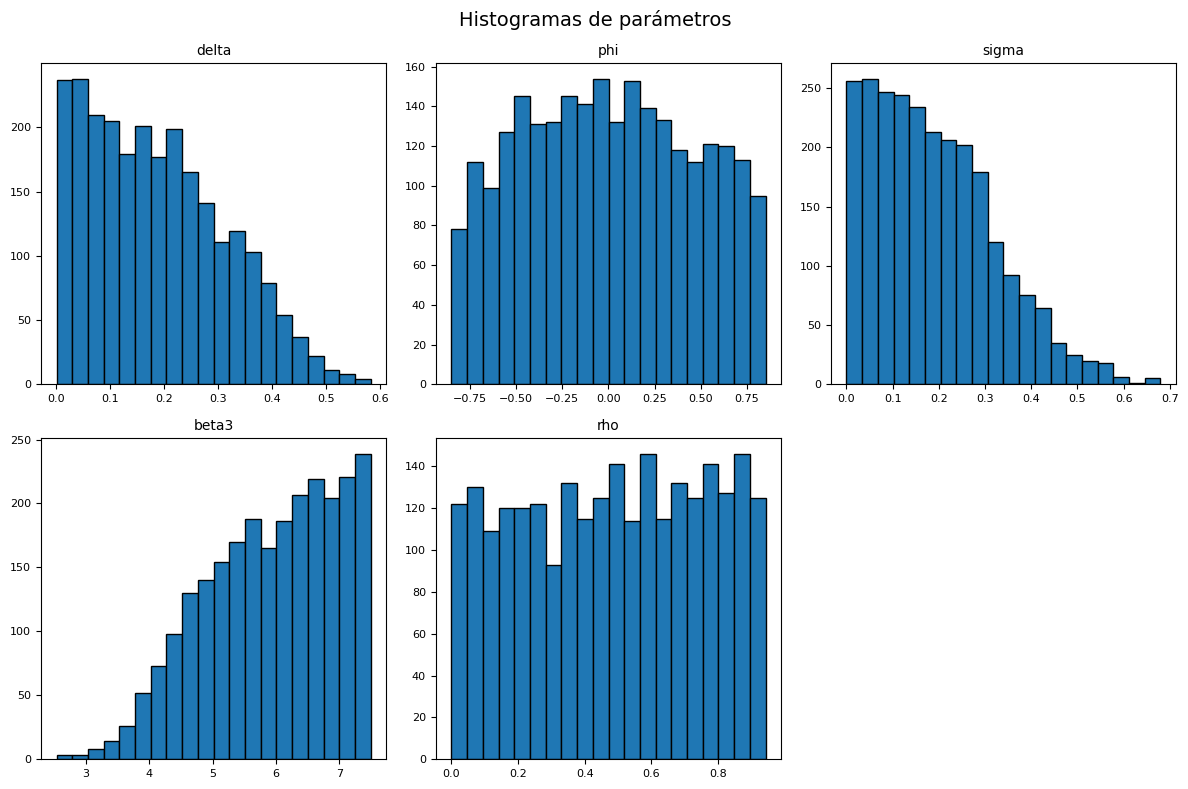

In [33]:
# ABC
histograma_parametros_modelo(dt_errores, D_corrida, M_corrida, error_columna = "errorMSE", p = 0.01)

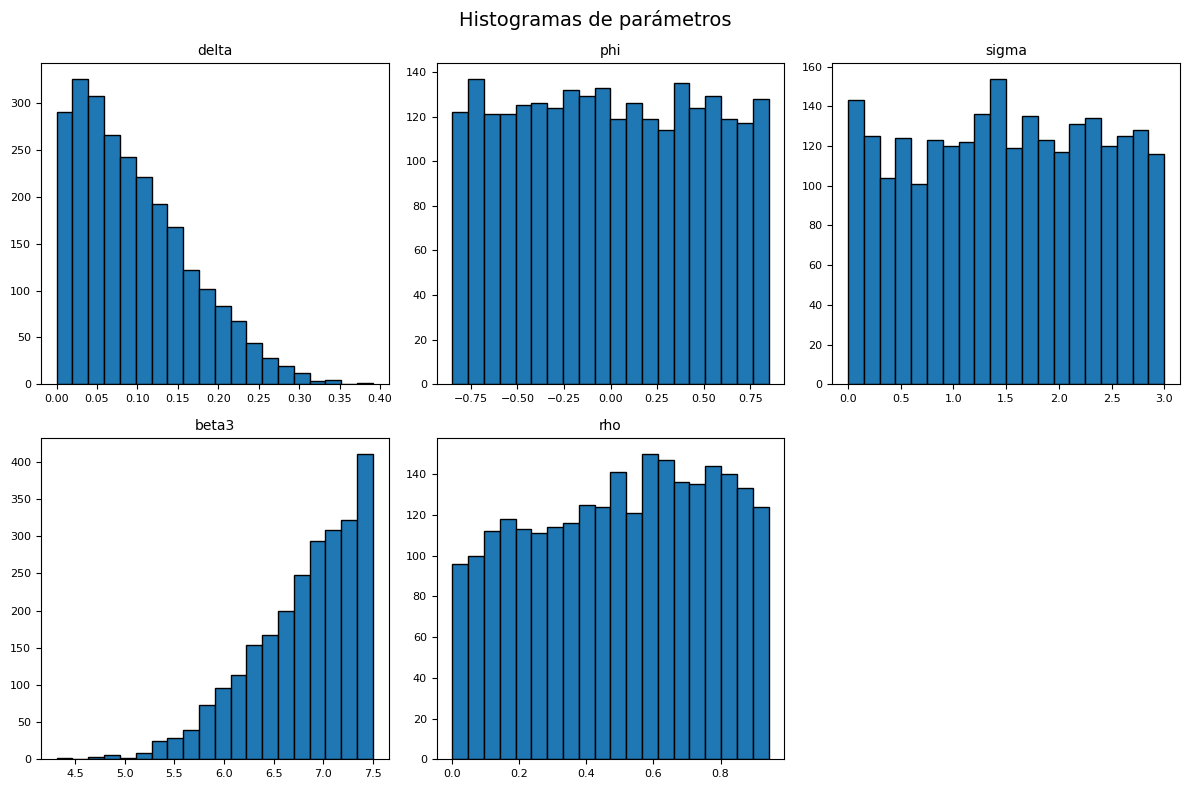

In [34]:
# ABC
histograma_parametros_modelo(dt_errores, "D3", "M1", error_columna = "errorMSE", p = 0.01)

In [ ]:
resumen_test = comparar_test_DyM(
    datos_santos_test2,
    m_testing_santos,
    nsites_santos,
    dist_mat_santos,
    dt_errores,
    n_simulaciones=1000,
    p=0.01
)

In [ ]:
print(resumen_test)

In [40]:
simulaciones_test = corrida_n_simulaciones_precipitaciones(m_testing_santos, nsites_santos, dist_mat_santos, 'D3', 'M1', dt_errores, n_simulaciones=1000, datos_prepivot=datos_santos_test2)

In [53]:
def plot_qq_bandas_ubicaciones(
    simulaciones,
    datos_prepivot,
    ubic=None,
    max_plots=None,
    q=np.linspace(0.01, 0.99, 50),
    ncols=5,
    figsize_por_plot=(3, 3.2)
):
    chirps_pivot = datos_prepivot.pivot(
        index="date",
        columns=["lat", "lon"],
        values="chirps"
    )

    columnas = chirps_pivot.columns
    chirps = chirps_pivot.values
    if max_plots is None:
        max_plots = ubic.shape[0]
    ubic = ubic.head(max_plots).reset_index(drop=True)

    nplots = ubic.shape[0]
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_por_plot[0] * ncols, figsize_por_plot[1] * nrows)
    )

    axes = np.array(axes).reshape(-1)

    for i, row in ubic.iterrows():
        lat, lon = row["lat"], row["lon"]

        if (lat, lon) not in columnas:
            axes[i].axis("off")
            continue

        j = columnas.get_loc((lat, lon))

        obs_q = np.quantile(chirps[:, j], q)

        sim_q = np.quantile(simulaciones[:, :, j], q, axis=1).T
        sim_q_med = np.median(sim_q, axis=0)
        sim_q_low = np.quantile(sim_q, 0.025, axis=0)
        sim_q_high = np.quantile(sim_q, 0.975, axis=0)

        min_val = min(obs_q.min(), sim_q_low.min())
        max_val = max(obs_q.max(), sim_q_high.max())

        axes[i].fill_between(obs_q, sim_q_low, sim_q_high, alpha=0.25)
        axes[i].plot(obs_q, sim_q_med, linestyle="--")
        axes[i].scatter(obs_q, sim_q_med, s=12)
        axes[i].plot([min_val, max_val], [min_val, max_val], linestyle=":")

        axes[i].set_title(f"lon: {lon}, lat {lat}", fontsize=10)
        axes[i].set_xlabel("Real")
        axes[i].set_ylabel("Simulado")
        axes[i].grid(True)

    for j in range(nplots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [1]:
plot_qq_bandas_ubicaciones(simulaciones_test, datos_santos_test2, ubic=ubic_santos)

NameError: name 'plot_qq_bandas_ubicaciones' is not defined

In [ ]:
from joblib import dump

dump(
    {
        "simulaciones_test": simulaciones_test,
        "resumen_test": resumen_test,
    },
    "workspace.joblib"
)

In [ ]:
from joblib import load

workspace = load("workspace.joblib")

simulaciones_test = workspace["simulaciones_test"]
resumen_test = workspace["resumen_test"]